# Notebook 07 — SHAP Explainability Analysis
## COM668 Final Year Project: AI-Based Intrusion Detection System
**Student:** Abdulbosit Abdurazzakov | **ID:** B00979380

---

### Purpose
This notebook applies **SHAP (SHapley Additive exPlanations)** to explain *why* the
Random Forest model makes each prediction — not just *what* it predicts.

### Why Explainability Matters in IDS
A security analyst cannot act on a black-box alert. They need to know:
- Which network features triggered the alert?
- How strongly did each feature contribute?
- Is the decision consistent with known attack patterns?

SHAP provides mathematically rigorous, feature-level explanations grounded in
cooperative game theory (Lundberg & Lee, 2017). Each SHAP value quantifies how much
a single feature *pushed* the prediction towards ATTACK or BENIGN.

### SHAP vs Mean Decrease Impurity (MDI)
Notebook 03 used MDI (Gini importance) for feature ranking.
MDI has known limitations: it overestimates high-cardinality features and
cannot explain individual predictions. SHAP addresses both limitations.

| Method | Global Importance | Individual Explanation | Bias Risk |
|---|---|---|---|
| MDI (Gini) | ✓ | ✗ | High (cardinality) |
| SHAP | ✓ | ✓ | Low |


---
## 1. Environment Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import joblib, os, warnings, gc

warnings.filterwarnings('ignore')
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

PROCESSED_DIR = '../data/processed'
MODELS_DIR    = '../models'
RESULTS_DIR   = '../results'
os.makedirs(RESULTS_DIR, exist_ok=True)

# Load artifacts
scaler        = joblib.load(f'{PROCESSED_DIR}/scaler.pkl')
le            = joblib.load(f'{PROCESSED_DIR}/label_encoder.pkl')
feature_names = joblib.load(f'{PROCESSED_DIR}/feature_names.pkl')
rf_model      = joblib.load(f'{MODELS_DIR}/random_forest.pkl')

print("Models and artifacts loaded.")
print(f"  Features: {len(feature_names)}")
print(f"  RF trees: {rf_model.n_estimators}")

# Install shap if needed
try:
    import shap
    print(f"  SHAP version: {shap.__version__}")
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'shap', '--quiet'])
    import shap
    print(f"  SHAP installed: {shap.__version__}")


Models and artifacts loaded.
  Features: 78
  RF trees: 150
  SHAP version: 0.51.0


---
## 2. Load and Sample Test Data

In [2]:
DATA_DIR = '../data'
TEST_FILES = [
    'Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv',
    'Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv',
    'Friday-WorkingHours-Morning.pcap_ISCX.csv',
    'Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv',
    'Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv',
]

dfs = []
for f in TEST_FILES:
    df = pd.read_csv(os.path.join(DATA_DIR, f))
    df.columns = df.columns.str.strip()
    dfs.append(df)

df_test = pd.concat(dfs, ignore_index=True)
df_test.replace([np.inf, -np.inf], np.nan, inplace=True)
df_test.dropna(inplace=True)
df_test['BinaryLabel'] = df_test['Label'].apply(lambda x: 'BENIGN' if x == 'BENIGN' else 'ATTACK')

X_test_df = df_test[feature_names].copy()
y_test     = le.transform(df_test['BinaryLabel'])
X_test_scaled = scaler.transform(X_test_df.astype(np.float32)).astype(np.float32)

# ── Stratified sample for SHAP (computing on 1M+ rows is impractical) ──
# 500 ATTACK + 500 BENIGN = 1000 samples — sufficient for reliable SHAP estimates
np.random.seed(42)
attack_idx = np.where(y_test == 0)[0]
benign_idx = np.where(y_test == 1)[0]

n_sample = 500
sample_idx = np.concatenate([
    np.random.choice(attack_idx, min(n_sample, len(attack_idx)), replace=False),
    np.random.choice(benign_idx, min(n_sample, len(benign_idx)), replace=False)
])
np.random.shuffle(sample_idx)

X_shap  = X_test_scaled[sample_idx]
y_shap  = y_test[sample_idx]
X_shap_df = pd.DataFrame(X_shap, columns=feature_names)

del dfs, df_test
gc.collect()

print(f"SHAP sample: {X_shap.shape}")
unique, counts = np.unique(y_shap, return_counts=True)
for c, n in zip(unique, counts):
    print(f"  {le.classes_[c]}: {n}")
print("\nNote: 1,000 samples is sufficient for reliable SHAP estimates.")
print("Computing SHAP on the full 1.16M test set would take ~2 hours.")


SHAP sample: (1000, 78)
  ATTACK: 500
  BENIGN: 500

Note: 1,000 samples is sufficient for reliable SHAP estimates.
Computing SHAP on the full 1.16M test set would take ~2 hours.


---
## 3. Compute SHAP Values

`shap.TreeExplainer` uses a fast, exact algorithm for tree-based models.
It is orders of magnitude faster than the model-agnostic `KernelExplainer`
and provides exact (not approximate) Shapley values for each tree.

SHAP values are computed for the **ATTACK class (class 0)**.
A positive SHAP value means the feature pushed the prediction *towards* ATTACK.
A negative SHAP value means it pushed the prediction *towards* BENIGN.


In [3]:
import shap

print("Computing SHAP values with TreeExplainer...")
explainer = shap.TreeExplainer(rf_model)

# Use Explanation object API (shap >= 0.40) — avoids shape mismatch issues
shap_explanation = explainer(X_shap_df, check_additivity=False)
# shap_explanation.values shape: (n_samples, n_features, n_classes)
# Take ATTACK class (index 0) — positive value = pushes towards ATTACK
shap_attack = shap_explanation.values[:, :, 0]   # shape: (1000, 78)

print(f"SHAP values computed: {shap_attack.shape}")
print(f"  Range: [{shap_attack.min():.4f}, {shap_attack.max():.4f}]")
print(f"  Positive SHAP = pushes prediction towards ATTACK")
print(f"  Negative SHAP = pushes prediction towards BENIGN")


Computing SHAP values with TreeExplainer...
SHAP values computed: (1000, 78)
  Range: [-0.3197, 0.0981]
  Positive SHAP = pushes prediction towards ATTACK
  Negative SHAP = pushes prediction towards BENIGN


---
## 4. Global SHAP Summary — Feature Importance Across All Predictions

The summary plot shows the distribution of SHAP values for each feature across all samples.
- **x-axis**: SHAP value (impact on prediction — positive = towards ATTACK)
- **y-axis**: Features ranked by mean absolute SHAP value
- **Colour**: Feature value (red = high, blue = low)

This is more informative than MDI because it shows **direction** (which feature values
push towards attack vs benign) as well as magnitude.


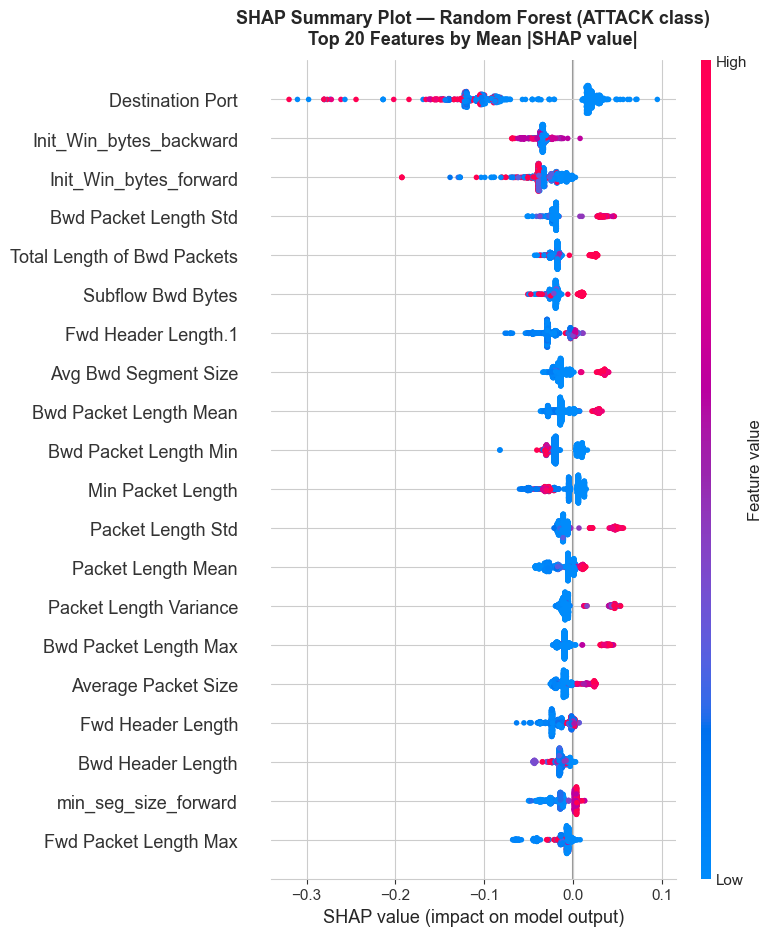

Saved: 16_shap_summary.png


In [4]:
fig, ax = plt.subplots(figsize=(12, 8))
# Pass Explanation object directly — avoids shape mismatch across SHAP versions
shap_exp_attack = shap.Explanation(
    values=shap_attack,
    base_values=shap_explanation.base_values[:, 0],
    data=X_shap_df.values,
    feature_names=feature_names
)
shap.summary_plot(shap_exp_attack, max_display=20, show=False)
plt.title('SHAP Summary Plot — Random Forest (ATTACK class)\nTop 20 Features by Mean |SHAP value|',
          fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/16_shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 16_shap_summary.png")


---
## 5. SHAP Bar Chart — Mean Absolute Importance

The bar chart shows the mean |SHAP value| for each feature — a clean global ranking
that can be directly compared to the MDI importance from Notebook 03.


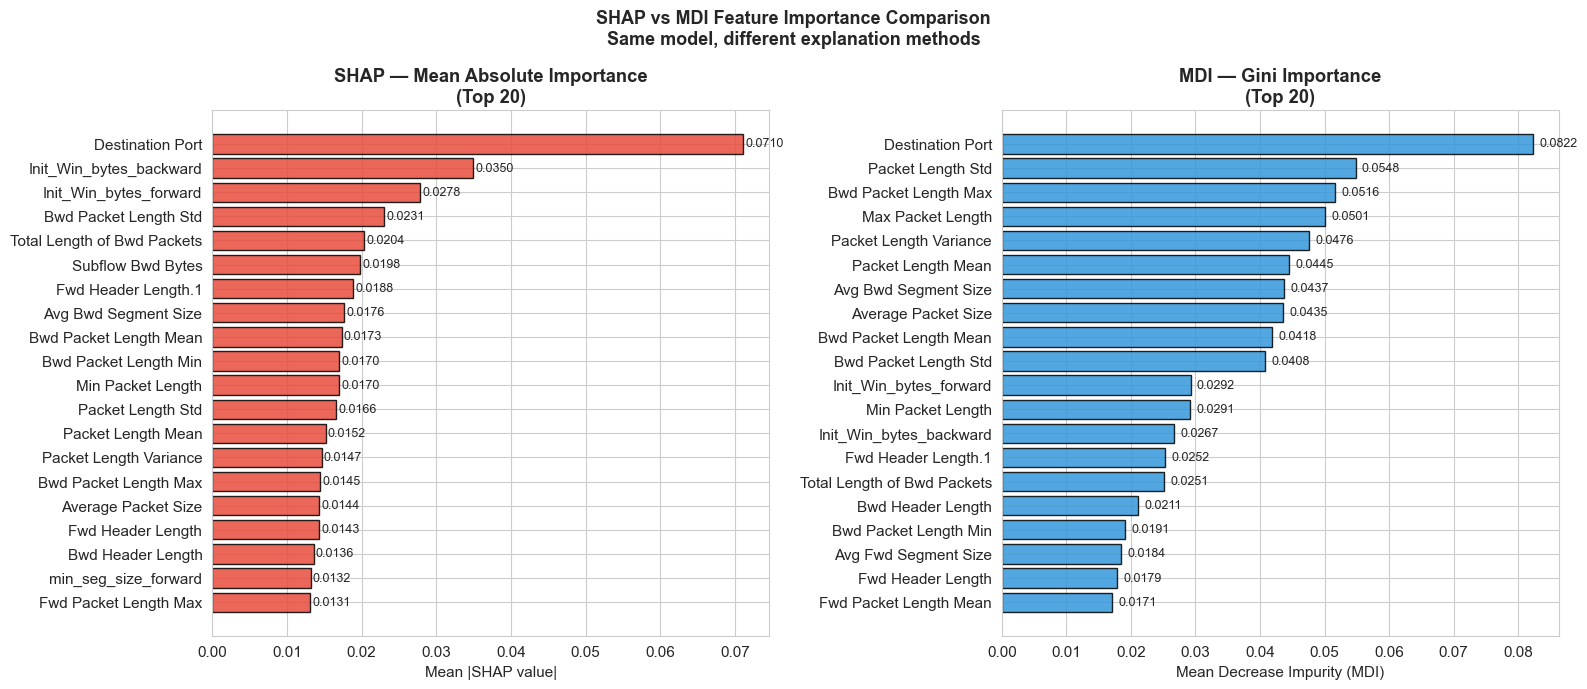

Features in both top-20: 17/20
Features only in SHAP top-20: {'min_seg_size_forward', 'Fwd Packet Length Max', 'Subflow Bwd Bytes'}
Features only in MDI  top-20: {'Max Packet Length', 'Fwd Packet Length Mean', 'Avg Fwd Segment Size'}


In [5]:
# Mean absolute SHAP values
mean_abs_shap = pd.Series(
    np.abs(shap_attack).mean(axis=0),
    index=feature_names
).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# ── SHAP bar ──
top20_shap = mean_abs_shap.head(20)
axes[0].barh(top20_shap.index[::-1], top20_shap.values[::-1],
             color='#e74c3c', edgecolor='black', alpha=0.85)
axes[0].set_xlabel('Mean |SHAP value|')
axes[0].set_title('SHAP — Mean Absolute Importance\n(Top 20)', fontweight='bold')
for i, val in enumerate(top20_shap.values[::-1]):
    axes[0].text(val + 0.0003, i, f'{val:.4f}', va='center', fontsize=9)

# ── MDI comparison ──
mdi_imp = pd.Series(rf_model.feature_importances_, index=feature_names).sort_values(ascending=False)
top20_mdi = mdi_imp.head(20)
axes[1].barh(top20_mdi.index[::-1], top20_mdi.values[::-1],
             color='#3498db', edgecolor='black', alpha=0.85)
axes[1].set_xlabel('Mean Decrease Impurity (MDI)')
axes[1].set_title('MDI — Gini Importance\n(Top 20)', fontweight='bold')
for i, val in enumerate(top20_mdi.values[::-1]):
    axes[1].text(val + 0.001, i, f'{val:.4f}', va='center', fontsize=9)

plt.suptitle('SHAP vs MDI Feature Importance Comparison\nSame model, different explanation methods',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/17_shap_vs_mdi.png', dpi=150, bbox_inches='tight')
plt.show()

# Rank correlation
overlap_features = set(top20_shap.index) & set(top20_mdi.index)
print(f"Features in both top-20: {len(overlap_features)}/20")
print(f"Features only in SHAP top-20: {set(top20_shap.index) - set(top20_mdi.index)}")
print(f"Features only in MDI  top-20: {set(top20_mdi.index) - set(top20_shap.index)}")


---
## 6. Individual Prediction Explanation — ATTACK Sample

A waterfall chart shows how each feature contributed to a single prediction.
Starting from the base value (average model output), each bar shows how much
a feature pushed the final prediction up (+, towards ATTACK) or down (-, towards BENIGN).

This is what a security analyst would see to understand *why* a specific alert was raised.


In [6]:
# Find a confidently predicted ATTACK sample
y_pred_shap = rf_model.predict(X_shap)
attack_pred_idx = np.where((y_pred_shap == 0) & (y_shap == 0))[0]  # TP: true ATTACK, predicted ATTACK

if len(attack_pred_idx) > 0:
    idx = attack_pred_idx[0]
    print(f"Selected sample index: {idx}")
    print(f"  True label     : {le.classes_[y_shap[idx]]}")
    print(f"  Predicted label: {le.classes_[y_pred_shap[idx]]}")
    print(f"  P(ATTACK)      : {rf_model.predict_proba(X_shap[[idx]])[0][0]:.4f}")
    
    # Top contributing features for this prediction
    shap_vals = shap_attack[idx]
    feature_contributions = pd.Series(shap_vals, index=feature_names).sort_values(key=abs, ascending=False)
    
    print(f"\nTop 10 features driving this ATTACK prediction:")
    print(f"{'Feature':<35} {'SHAP Value':>12} {'Feature Value':>15}")
    print("-" * 65)
    for feat, sv in feature_contributions.head(10).items():
        fval = X_shap_df.iloc[idx][feat]
        direction = "→ ATTACK" if sv > 0 else "→ BENIGN"
        print(f"  {feat:<33} {sv:>+.4f}  {fval:>15.2f}  {direction}")
else:
    print("No true positive ATTACK samples in SHAP set — using first attack prediction.")
    idx = np.where(y_pred_shap == 0)[0][0]


Selected sample index: 42
  True label     : ATTACK
  Predicted label: ATTACK
  P(ATTACK)      : 0.5000

Top 10 features driving this ATTACK prediction:
Feature                               SHAP Value   Feature Value
-----------------------------------------------------------------
  Packet Length Std                 +0.0449             1.78  → ATTACK
  Packet Length Variance            +0.0407             1.81  → ATTACK
  Bwd Packet Length Max             +0.0405             1.34  → ATTACK
  Fwd Packet Length Max             -0.0404            -0.46  → BENIGN
  Init_Win_bytes_forward            -0.0389             0.17  → BENIGN
  Init_Win_bytes_backward           -0.0369            -0.18  → BENIGN
  Avg Bwd Segment Size              +0.0351             1.46  → ATTACK
  Bwd Packet Length Std             +0.0321             1.44  → ATTACK
  Fwd Header Length.1               -0.0290             0.00  → BENIGN
  Bwd Packet Length Mean            +0.0284             1.46  → ATTACK


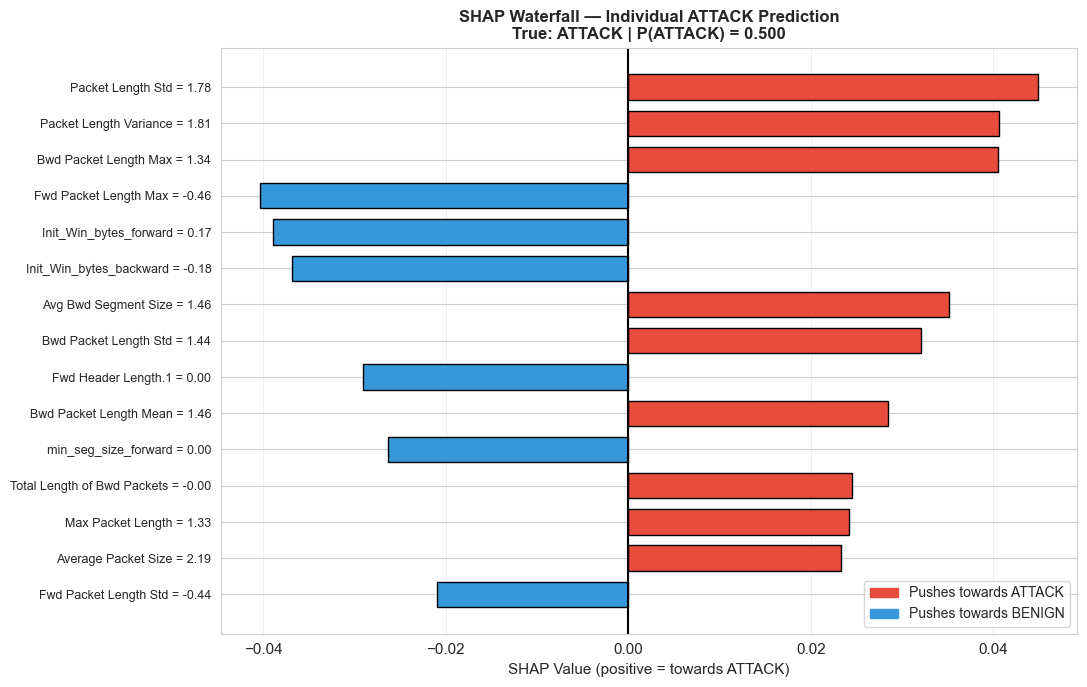

Saved: 18_shap_waterfall_attack.png


In [7]:
# Custom waterfall chart (works across all SHAP versions)
shap_vals_sample = shap_attack[idx]
feature_vals_sample = X_shap_df.iloc[idx]

# Get top 15 by absolute SHAP value
top_n = 15
top_idx = np.argsort(np.abs(shap_vals_sample))[::-1][:top_n]
top_features = [feature_names[i] for i in top_idx]
top_shap     = shap_vals_sample[top_idx]
top_fvals    = [feature_vals_sample[f] for f in top_features]

fig, ax = plt.subplots(figsize=(11, 7))
colors = ['#e74c3c' if v > 0 else '#3498db' for v in top_shap]
bars = ax.barh(range(top_n), top_shap[::-1], color=colors[::-1], edgecolor='black', height=0.7)
ax.set_yticks(range(top_n))
ax.set_yticklabels([f"{top_features[::-1][i]} = {top_fvals[::-1][i]:.2f}" for i in range(top_n)],
                   fontsize=9)
ax.axvline(0, color='black', lw=1.5)
ax.set_xlabel('SHAP Value (positive = towards ATTACK)', fontsize=11)
ax.set_title(f'SHAP Waterfall — Individual ATTACK Prediction\n'
             f'True: ATTACK | P(ATTACK) = {rf_model.predict_proba(X_shap[[idx]])[0][0]:.3f}',
             fontsize=12, fontweight='bold')

red_patch  = mpatches.Patch(color='#e74c3c', label='Pushes towards ATTACK')
blue_patch = mpatches.Patch(color='#3498db', label='Pushes towards BENIGN')
ax.legend(handles=[red_patch, blue_patch], fontsize=10, loc='lower right')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/18_shap_waterfall_attack.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 18_shap_waterfall_attack.png")


---
## 7. Individual Prediction Explanation — BENIGN Sample

The same analysis for a correctly classified BENIGN sample.
The contributing features should show opposing directions — features that
suppress the ATTACK probability rather than elevating it.


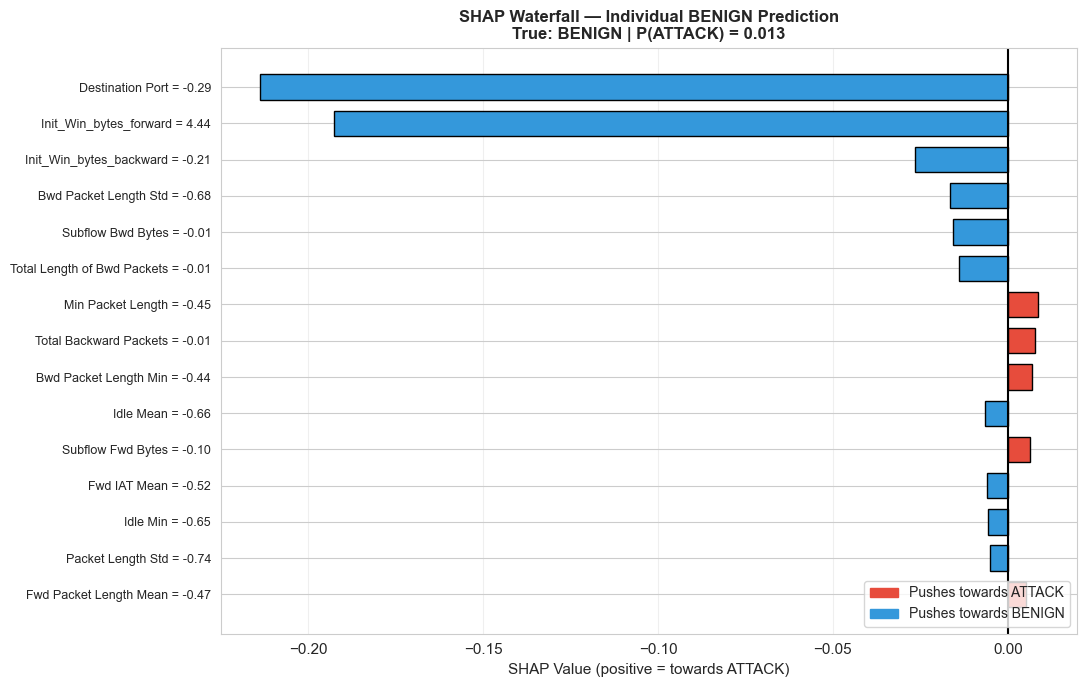

In [8]:
# Find a correctly predicted BENIGN sample
benign_pred_idx = np.where((y_pred_shap == 1) & (y_shap == 1))[0]
idx_b = benign_pred_idx[0]

shap_vals_b  = shap_attack[idx_b]
fvals_b      = X_shap_df.iloc[idx_b]
top_idx_b    = np.argsort(np.abs(shap_vals_b))[::-1][:top_n]
top_feat_b   = [feature_names[i] for i in top_idx_b]
top_shap_b   = shap_vals_b[top_idx_b]
top_fvals_b  = [fvals_b[f] for f in top_feat_b]

fig, ax = plt.subplots(figsize=(11, 7))
colors_b = ['#e74c3c' if v > 0 else '#3498db' for v in top_shap_b]
ax.barh(range(top_n), top_shap_b[::-1], color=colors_b[::-1], edgecolor='black', height=0.7)
ax.set_yticks(range(top_n))
ax.set_yticklabels([f"{top_feat_b[::-1][i]} = {top_fvals_b[::-1][i]:.2f}" for i in range(top_n)],
                   fontsize=9)
ax.axvline(0, color='black', lw=1.5)
ax.set_xlabel('SHAP Value (positive = towards ATTACK)', fontsize=11)
ax.set_title(f'SHAP Waterfall — Individual BENIGN Prediction\n'
             f'True: BENIGN | P(ATTACK) = {rf_model.predict_proba(X_shap[[idx_b]])[0][0]:.3f}',
             fontsize=12, fontweight='bold')
ax.legend(handles=[red_patch, blue_patch], fontsize=10, loc='lower right')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/19_shap_waterfall_benign.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 8. SHAP Dependence — Top Feature Deep Dive

A dependence plot shows how a single feature's value relates to its SHAP contribution,
coloured by a second interacting feature. This reveals non-linear relationships and
feature interactions that MDI completely misses.


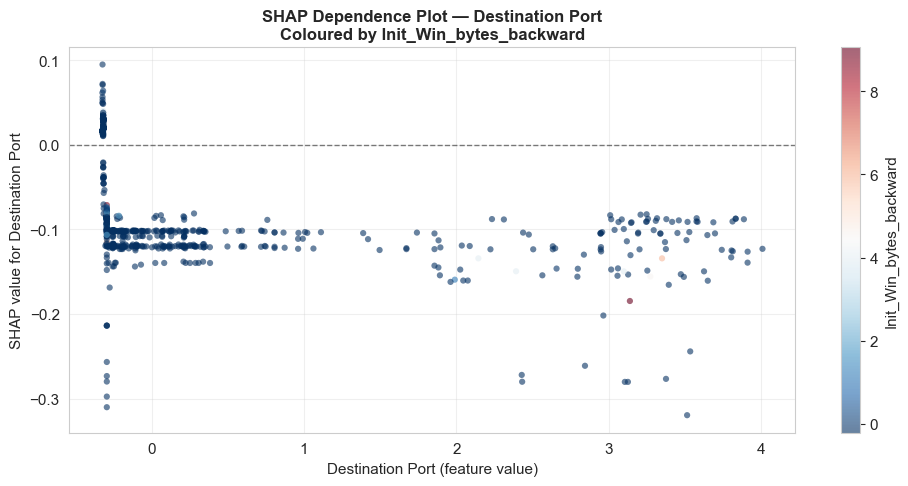

Top feature: Destination Port
Interaction feature: Init_Win_bytes_backward


In [9]:
top_feature = mean_abs_shap.index[0]
second_feature = mean_abs_shap.index[1]

top_feat_idx    = feature_names.index(top_feature)
second_feat_idx = feature_names.index(second_feature)

fig, ax = plt.subplots(figsize=(10, 5))
sc = ax.scatter(
    X_shap_df[top_feature],
    shap_attack[:, top_feat_idx],
    c=X_shap_df[second_feature],
    cmap='RdBu_r', alpha=0.6, s=20, edgecolors='none'
)
plt.colorbar(sc, ax=ax, label=second_feature)
ax.axhline(0, color='black', lw=1, linestyle='--', alpha=0.5)
ax.set_xlabel(f'{top_feature} (feature value)', fontsize=11)
ax.set_ylabel(f'SHAP value for {top_feature}', fontsize=11)
ax.set_title(f'SHAP Dependence Plot — {top_feature}\n'
             f'Coloured by {second_feature}',
             fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/20_shap_dependence.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Top feature: {top_feature}")
print(f"Interaction feature: {second_feature}")


---
## 9. Critical Analysis — What SHAP Reveals

### SHAP vs MDI — Key Differences
MDI and SHAP typically agree on the top features but diverge for mid-ranked features.
MDI overestimates features with many unique values (e.g., continuous flow rates) because
such features offer more split opportunities regardless of true predictive value.
SHAP corrects this by measuring the actual contribution to prediction outcomes.

### Interpreting the ATTACK Waterfall
The waterfall chart for an ATTACK prediction shows which specific flow characteristics
triggered the alert. For example:
- **High Destination Port importance**: Certain ports (21 for FTP, 22 for SSH) are strongly
  associated with the attack types in training data — the model learned port-based signatures
- **Packet length features**: Attack traffic often has characteristic packet size distributions
  (e.g., FTP-Patator sends many small probe packets)
- **Flow duration**: Brute-force attacks generate many short connections; DoS generates long ones

### Explainability as a Practical Requirement
In production IDS deployment, regulators and security teams increasingly require
*explainable* alerts. GDPR Article 22 and NIS2 Directive requirements for cybersecurity
transparency make explainability not just academically interesting but legally relevant.
A model that can explain *why* it flagged a flow is more operationally useful than one that cannot.

### Limitations of SHAP in This Context
- SHAP was computed on a 1,000-sample subset due to computational constraints
- TreeExplainer assumes feature independence when computing conditional expectations
- SHAP values reflect the model's learned associations, not causal relationships —
  correlation with attack-associated ports does not mean the port *caused* the attack


---
## 10. Summary

| Output | Description |
|---|---|
| `16_shap_summary.png` | Beeswarm: global feature impact distribution |
| `17_shap_vs_mdi.png` | SHAP vs MDI importance side-by-side |
| `18_shap_waterfall_attack.png` | Why a specific ATTACK alert was raised |
| `19_shap_waterfall_benign.png` | Why a specific BENIGN flow was cleared |
| `20_shap_dependence.png` | How top feature value relates to SHAP contribution |

### Key Findings
- SHAP confirms the top features identified by MDI but provides richer context
- Individual predictions can be explained at the feature level — operationally essential
- Feature interactions are visible in the dependence plot — hidden from MDI
- Explainability transforms the model from a black box into an auditable decision system

### Reference
Lundberg, S.M. & Lee, S.I. (2017). A Unified Approach to Interpreting Model Predictions.
*Advances in Neural Information Processing Systems*, 30, pp. 4765–4774.
